# Train Greeting Subset v2

## Verify the dataset


In [3]:
# Fix import resolution for the repository-local `src` package
import sys
from pathlib import Path

REPO_ROOT = Path(r'C:\Projects\signia-fsl-recognition').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Install the repository package in editable mode when needed
# (use this once in the environment so `src` resolves consistently)
# %pip install -e .

import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from src.datasets import GreetingDataset
from src.models.sign_lstm import SignLSTM
from src.preprocessing.greeting_features import (
    add_motion_features,
    normalize_sequence,
)
from src.training import evaluate, train_one_epoch


## Set the random seed


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Seed:', SEED)


Seed: 42


## Choose device


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Device: cpu


## Load the dataset


In [6]:
DATA_PATH = r'C:\Projects\signia-fsl-recognition\notebooks\02_dynamic\fsl_dataset_clean.pt'

data = np.load(DATA_PATH, allow_pickle=True)
print(data.files)


['fsl_dataset_clean/data.pkl', 'fsl_dataset_clean/.format_version', 'fsl_dataset_clean/.storage_alignment', 'fsl_dataset_clean/byteorder', 'fsl_dataset_clean/data/0', 'fsl_dataset_clean/data/1', 'fsl_dataset_clean/version', 'fsl_dataset_clean/.data/serialization_id']


In [15]:
import torch

DATA_PATH = r"C:\Projects\signia-fsl-recognition\notebooks\02_dynamic\fsl_dataset_clean.pt"

data = torch.load(
    DATA_PATH,
    map_location="cpu",
    weights_only=False
)

print("Data type:", type(data))

if isinstance(data, dict):
    print("\nData keys:")
    for key, value in data.items():
        print(
            f"  {key}: "
            f"type={type(value)}, "
            f"shape={getattr(value, 'shape', None)}"
        )
else:
    print(data)

Data type: <class 'dict'>

Data keys:
  X: type=<class 'torch.Tensor'>, shape=torch.Size([2129, 30, 126])
  y: type=<class 'torch.Tensor'>, shape=torch.Size([2129])


## Inspect label counts


In [16]:
# Inspect label distribution

X = data["X"]
y = data["y"]

print("X shape:", X.shape)
print("y shape:", y.shape)

unique_labels, counts = torch.unique(
    y,
    return_counts=True
)

print("\nNumber of unique labels:", len(unique_labels))

for label, count in zip(unique_labels, counts):
    print(f"Label {label.item():>3}: {count.item():>4} samples")

X shape: torch.Size([2129, 30, 126])
y shape: torch.Size([2129])

Number of unique labels: 105
Label   0:   20 samples
Label   1:   21 samples
Label   2:   22 samples
Label   3:   20 samples
Label   4:   21 samples
Label   5:   20 samples
Label   6:   22 samples
Label   7:   20 samples
Label   8:   20 samples
Label   9:   20 samples
Label  10:   20 samples
Label  11:   21 samples
Label  12:   21 samples
Label  13:   20 samples
Label  14:   21 samples
Label  15:   20 samples
Label  16:   21 samples
Label  17:   22 samples
Label  18:   21 samples
Label  19:   21 samples
Label  20:   20 samples
Label  21:   20 samples
Label  22:   20 samples
Label  23:   20 samples
Label  24:   20 samples
Label  25:   20 samples
Label  26:   21 samples
Label  27:   20 samples
Label  28:   20 samples
Label  29:   20 samples
Label  30:   20 samples
Label  31:   19 samples
Label  32:   20 samples
Label  33:   20 samples
Label  34:   21 samples
Label  35:   20 samples
Label  36:   21 samples
Label  37:   22 s

In [13]:
from pathlib import Path

path = Path(DATA_PATH)

print("Path:", path)
print("Exists:", path.exists())
print("File:", path.is_file())
print("Size:", path.stat().st_size if path.exists() else "N/A")
print("Suffix:", path.suffix)

Path: C:\Projects\signia-fsl-recognition\notebooks\02_dynamic\fsl_dataset_clean.pt
Exists: True
File: True
Size: 32209461
Suffix: .pt


In [14]:
with open(DATA_PATH, "rb") as f:
    header = f.read(32)

print(header)

b'PK\x03\x04\x00\x00\x08\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x1a\x00\x08\x00fs'


In [17]:
print("\nFirst 50 labels:")
print(y[:50].tolist())

print("\nLabel dtype:", y.dtype)
print("X dtype:", X.dtype)
print("X min:", X.min().item())
print("X max:", X.max().item())


First 50 labels:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Label dtype: torch.int64
X dtype: torch.float32
X min: -1.0
X max: 1.0


In [18]:
import pickle

with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

print('Data type:', type(data))
print ('Data keys:', data.keys() if isinstance(data, dict) else dir(data))
print('Data files:', data.files)

payload_key = next((name for name in data.files if name.endswith('data.pkl')), None)
if payload_key is None:
    raise KeyError("No pickled dataset payload found in")
y = data['y']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Number of samples:', len(X))
print('Number of labels:', len(y))


UnpicklingError: A load persistent id instruction was encountered,
but no persistent_load function was specified.

In [10]:
print(data.files)


['fsl_dataset_clean/data.pkl', 'fsl_dataset_clean/.format_version', 'fsl_dataset_clean/.storage_alignment', 'fsl_dataset_clean/byteorder', 'fsl_dataset_clean/data/0', 'fsl_dataset_clean/data/1', 'fsl_dataset_clean/version', 'fsl_dataset_clean/.data/serialization_id']


## Define greeting classes


In [19]:
class_counts = Counter(y)
print('Number of classes:', len(class_counts))
for label, count in sorted(class_counts.items()):
    print(label, count)


Number of classes: 2129
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(0) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(1) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(2) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tensor(3) 1
tens

## Remap labels


In [20]:
GREETING_CLASSES = {
    0: 'Good Morning',
    1: 'Good Afternoon',
    2: 'Good Evening',
    3: 'Hello',
    4: 'How Are You',
}
GREETING_IDS = list(GREETING_CLASSES.keys())
print(GREETING_CLASSES)


{0: 'Good Morning', 1: 'Good Afternoon', 2: 'Good Evening', 3: 'Hello', 4: 'How Are You'}


## Class distribution


In [22]:
X_greetings = X[mask]
y_greetings_original = y[mask]

label_mapping = {
    original_label: new_label
    for new_label, original_label in enumerate(GREETING_IDS)
}

y_greetings = np.array([
    label_mapping[int(label)]
    for label in y_greetings_original
])

print('Greeting dataset:', X_greetings.shape)
print('Labels:', y_greetings.shape)
print('Unique labels:', np.unique(y_greetings))

Greeting dataset: torch.Size([104, 30, 126])
Labels: (104,)
Unique labels: [0 1 2 3 4]


## Sequence checks


In [25]:
def print_distribution(name, labels):
    print(f'{name}')
    for label, class_name in GREETING_CLASSES.items():
        count = np.sum(labels == label)
        print(f'{class_name:<20}: {count}')


print_distribution('TRAIN', y_greetings)


TRAIN
Good Morning        : 20
Good Afternoon      : 21
Good Evening        : 22
Hello               : 20
How Are You         : 21


## Train/Validation/Test split from scikit learn


In [27]:
empty_sequences = torch.all(X_greetings == 0, dim=(1, 2))

print('Empty sequences:', empty_sequences.sum().item())
print('Valid sequences:', (~empty_sequences).sum().item())
print('Minimum:', X_greetings.min())
print('Maximum:', X_greetings.max())
print('Mean:', X_greetings.mean())
print('Std:', X_greetings.std())


Empty sequences: 0
Valid sequences: 104
Minimum: tensor(-1.)
Maximum: tensor(1.)
Mean: tensor(-0.0536)
Std: tensor(0.2290)


## Split distribution


In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_greetings,
    y_greetings,
    test_size=0.30,
    random_state=SEED,
    stratify=y_greetings,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)


Train: torch.Size([72, 30, 126]) (72,)
Validation: torch.Size([16, 30, 126]) (16,)
Test: torch.Size([16, 30, 126]) (16,)


## Normalize sequences


In [29]:
print_distribution('TRAIN', y_train)
print_distribution('VALIDATION', y_val)
print_distribution('TEST', y_test)


TRAIN
Good Morning        : 14
Good Afternoon      : 15
Good Evening        : 15
Hello               : 14
How Are You         : 14
VALIDATION
Good Morning        : 3
Good Afternoon      : 3
Good Evening        : 3
Hello               : 3
How Are You         : 4
TEST
Good Morning        : 3
Good Afternoon      : 3
Good Evening        : 4
Hello               : 3
How Are You         : 3


## Add motion features


In [30]:
X_train_norm = np.array([normalize_sequence(seq) for seq in X_train])
X_val_norm = np.array([normalize_sequence(seq) for seq in X_val])
X_test_norm = np.array([normalize_sequence(seq) for seq in X_test])

print('Train:', X_train_norm.shape)
print('Validation:', X_val_norm.shape)
print('Test:', X_test_norm.shape)


Train: (72, 30, 126)
Validation: (16, 30, 126)
Test: (16, 30, 126)


## Create datasets and loaders


In [31]:
X_train_features = add_motion_features(X_train_norm)
X_val_features = add_motion_features(X_val_norm)
X_test_features = add_motion_features(X_test_norm)

print('Train:', X_train_features.shape)
print('Validation:', X_val_features.shape)
print('Test:', X_test_features.shape)


Train: (72, 30, 252)
Validation: (16, 30, 252)
Test: (16, 30, 252)


## Initialize Model


In [32]:
BATCH_SIZE = 8

train_dataset = GreetingDataset(X_train_features, y_train, augment=True)
val_dataset = GreetingDataset(X_val_features, y_val, augment=False)
test_dataset = GreetingDataset(X_test_features, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Test batches:', len(test_loader))


Train batches: 9
Validation batches: 2
Test batches: 2


## Train loop


In [33]:
model = SignLSTM(
    input_size=252,
    hidden_size=128,
    num_layers=2,
    num_classes=5,
    dropout=0.3,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)


SignLSTM(
  (lstm): LSTM(252, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)


## Plot accuracy


In [34]:
EPOCHS = 50
PATIENCE = 10
BEST_MODEL_PATH = 'best_greetings_lstm.pt'

best_val_acc = 0.0
epochs_without_improvement = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f'Epoch {epoch + 1:02d}/{EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Train Acc: {train_acc:.3f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val Acc: {val_acc:.3f}'
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print('  Saved best model')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print('Early stopping.')
        break

print('Best validation accuracy:', best_val_acc)


Epoch 01/50 | Train Loss: 1.5919 | Train Acc: 0.264 | Val Loss: 1.5366 | Val Acc: 0.438
  Saved best model
Epoch 02/50 | Train Loss: 1.4166 | Train Acc: 0.556 | Val Loss: 1.1805 | Val Acc: 0.500
  Saved best model
Epoch 03/50 | Train Loss: 1.0763 | Train Acc: 0.486 | Val Loss: 1.2680 | Val Acc: 0.375
Epoch 04/50 | Train Loss: 0.9781 | Train Acc: 0.528 | Val Loss: 0.9282 | Val Acc: 0.562
  Saved best model
Epoch 05/50 | Train Loss: 0.8683 | Train Acc: 0.556 | Val Loss: 0.7085 | Val Acc: 0.688
  Saved best model
Epoch 06/50 | Train Loss: 0.7272 | Train Acc: 0.639 | Val Loss: 0.6760 | Val Acc: 0.562
Epoch 07/50 | Train Loss: 0.7070 | Train Acc: 0.583 | Val Loss: 0.6501 | Val Acc: 0.625
Epoch 08/50 | Train Loss: 0.6520 | Train Acc: 0.653 | Val Loss: 0.6878 | Val Acc: 0.625
Epoch 09/50 | Train Loss: 0.6411 | Train Acc: 0.694 | Val Loss: 0.7687 | Val Acc: 0.500
Epoch 10/50 | Train Loss: 0.6699 | Train Acc: 0.653 | Val Loss: 0.7186 | Val Acc: 0.688
Epoch 11/50 | Train Loss: 0.6618 | Train Acc

## Plot loss


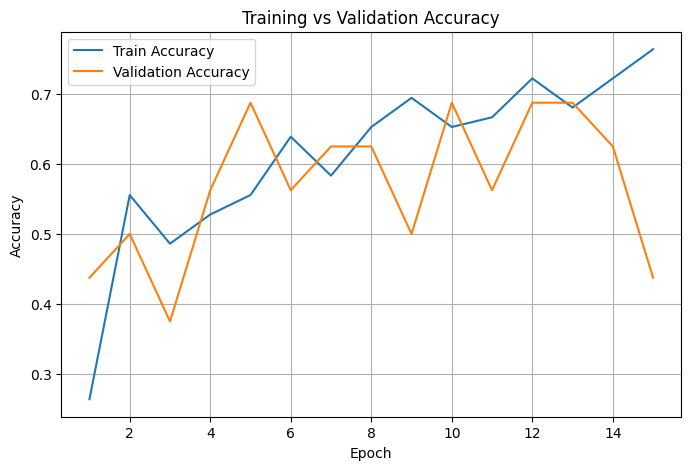

In [35]:
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_acc'], label='Train Accuracy')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## Save and load the best model


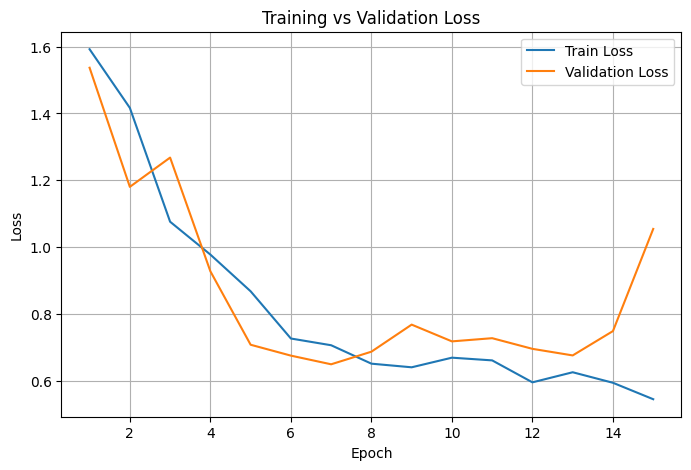

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


## Evaluate on test set


In [37]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
print('Loaded best model.')


Loaded best model.


## Collect predictions


In [38]:
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test accuracy: {test_accuracy * 100:.2f}%')


Test loss: 0.7520
Test accuracy: 0.6875
Test accuracy: 68.75%


## Classification report


In [39]:
all_predictions = []
all_targets = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(y_batch.numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

print('Predictions:', all_predictions)
print('Targets:', all_targets)


Predictions: [3 3 0 1 4 1 1 1 3 4 1 0 4 1 1 0]
Targets: [3 3 0 1 4 2 0 2 3 4 1 0 4 2 1 2]


## Confusion matrix


In [40]:
class_names = [GREETING_CLASSES[i] for i in range(5)]

print(
    classification_report(
        all_targets,
        all_predictions,
        labels=list(range(5)),
        target_names=class_names,
        zero_division=0,
    )
)


                precision    recall  f1-score   support

  Good Morning       0.67      0.67      0.67         3
Good Afternoon       0.43      1.00      0.60         3
  Good Evening       0.00      0.00      0.00         4
         Hello       1.00      1.00      1.00         3
   How Are You       1.00      1.00      1.00         3

      accuracy                           0.69        16
     macro avg       0.62      0.73      0.65        16
  weighted avg       0.58      0.69      0.61        16



In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Class names
class_names = [
    "Good Morning",
    "Good Afternoon",
    "Good Evening",
    "Hello",
    "How Are You"
]

# Put model in evaluation mode
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    predictions = torch.argmax(outputs, dim=1)

# Convert tensors to NumPy
y_true = y_test.cpu().numpy()
y_pred = predictions.cpu().numpy()

# Generate confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names))
)

# Print matrix
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - FSL Greeting Recognition")
plt.tight_layout()
plt.show()

RuntimeError: input.size(-1) must be equal to input_size. Expected 252, got 126

## Per-class accuracy


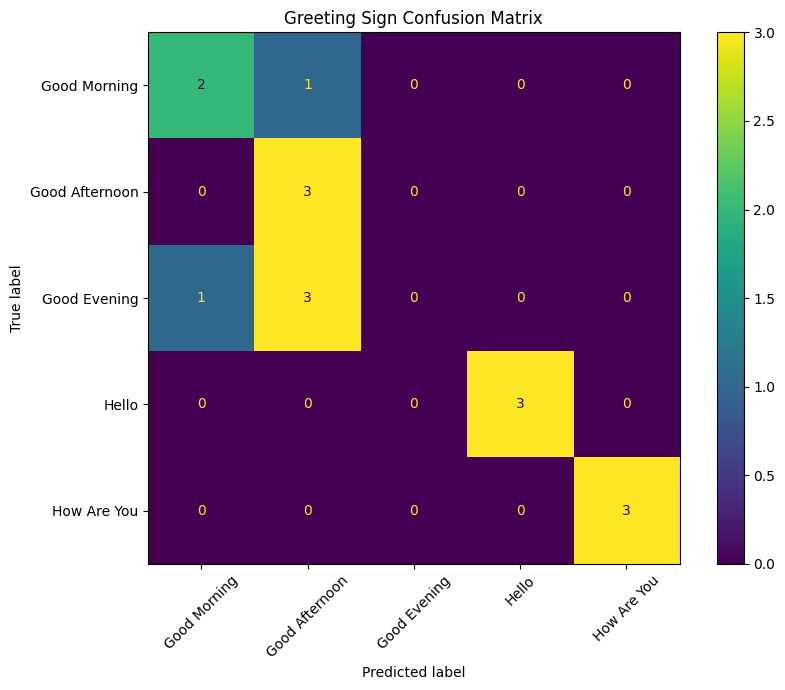

In [41]:
cm = confusion_matrix(all_targets, all_predictions, labels=list(range(5)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Greeting Sign Confusion Matrix')
plt.tight_layout()
plt.show()


In [42]:
for label, name in enumerate(class_names):
    mask = all_targets == label
    accuracy = 0 if mask.sum() == 0 else np.mean(all_predictions[mask] == label)
    print(f'{name:<20}: {accuracy * 100:.2f}% ({mask.sum()} samples)')


Good Morning        : 66.67% (3 samples)
Good Afternoon      : 100.00% (3 samples)
Good Evening        : 0.00% (4 samples)
Hello               : 100.00% (3 samples)
How Are You         : 100.00% (3 samples)


In [45]:
print(checkpoint["lstm.weight_ih_l0"].shape)
print(checkpoint["lstm.weight_hh_l0"].shape)
print(checkpoint["fc.weight"].shape)

torch.Size([512, 252])
torch.Size([512, 128])
torch.Size([5, 128])


In [47]:
from src.preprocessing.greeting_features import calculate_motion
import inspect

print(inspect.getsource(calculate_motion))

def calculate_motion(sequence):
    """
    Calculate frame-to-frame landmark movement.
    """

    sequence = np.asarray(sequence, dtype=np.float32)
    motion = np.zeros_like(sequence, dtype=np.float32)
    motion[1:] = sequence[1:] - sequence[:-1]
    return motion

